In [4]:

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [5]:

df= pd.read_csv("Mental-Health-Twitter.csv")
df.isnull().sum()
df.drop('Unnamed: 0', axis=1)


,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
19995,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,A day without sunshine is like night.,1169875706,442,230,7,1063601,0,0
19996,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,"Boren's Laws: (1) When in charge, ponder. (2) ...",1169875706,442,230,7,1063601,0,0
19997,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,The flow chart is a most thoroughly oversold p...,1169875706,442,230,7,1063601,0,0
19998,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,"Ships are safe in harbor, but they were never ...",1169875706,442,230,7,1063601,0,0


In [7]:

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemm = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r"http\S+|@\S+|#|\d+", "", text)   # remove URLs, mentions, hashtags, digits
    text = re.sub(r"[^A-Za-z\s]", "", text.lower().strip())  # keep only letters
    words = [lemm.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(words)

# apply to dataset
df['clean_tweet'] = df['post_text'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/snehasinha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/snehasinha/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_tweet'], df['label'], test_size=0.2, random_state=42
)

In [9]:

vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=300, class_weight='balanced'),
    "SVM (LinearSVC)": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


Logistic Regression

              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1981
           1       0.75      0.75      0.75      2019

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000



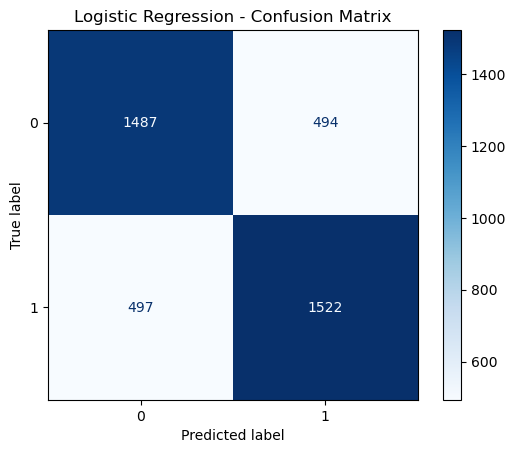


SVM (LinearSVC)

              precision    recall  f1-score   support

           0       0.75      0.76      0.75      1981
           1       0.76      0.75      0.76      2019

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000



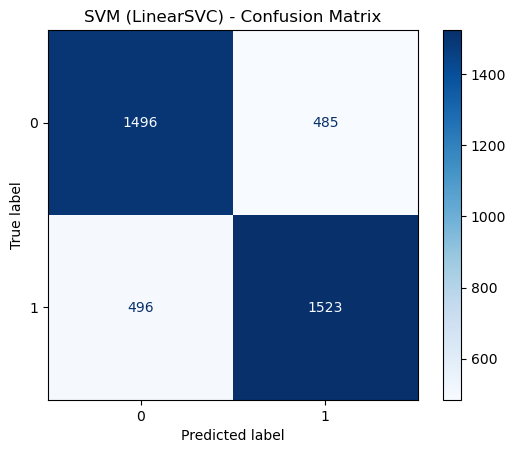


Naive Bayes

              precision    recall  f1-score   support

           0       0.78      0.73      0.76      1981
           1       0.75      0.79      0.77      2019

    accuracy                           0.76      4000
   macro avg       0.77      0.76      0.76      4000
weighted avg       0.77      0.76      0.76      4000



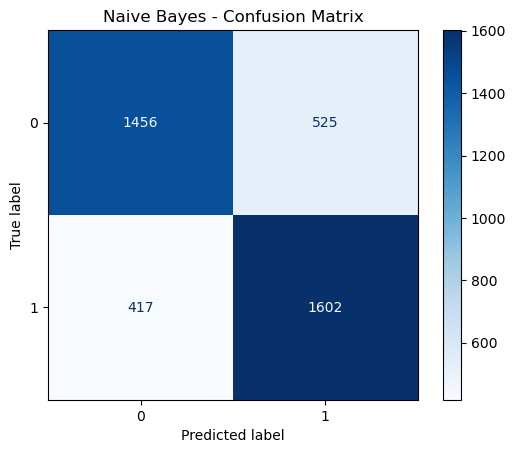


Random Forest

              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1981
           1       0.74      0.74      0.74      2019

    accuracy                           0.74      4000
   macro avg       0.74      0.74      0.74      4000
weighted avg       0.74      0.74      0.74      4000



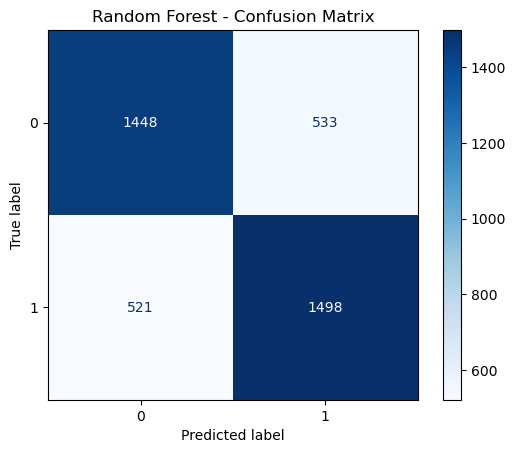


Gradient Boosting

              precision    recall  f1-score   support

           0       0.60      0.88      0.72      1981
           1       0.79      0.43      0.56      2019

    accuracy                           0.65      4000
   macro avg       0.69      0.66      0.64      4000
weighted avg       0.69      0.65      0.63      4000



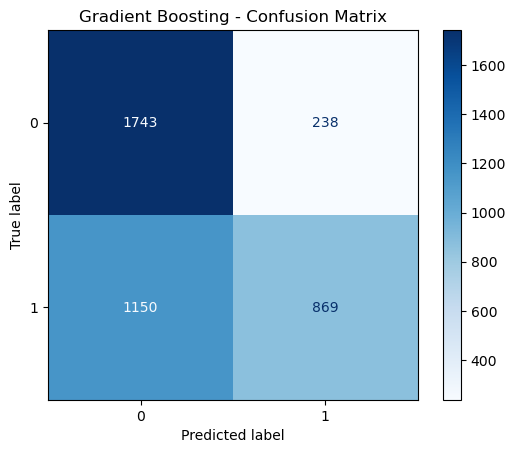

In [11]:

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = report['weighted avg']['f1-score']
    print(f"\n{name}\n{'='*50}\n")
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


In [12]:
best_model = LinearSVC()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

errors = pd.DataFrame({
    "tweet": X_test_text,
    "actual": y_test,
    "predicted": y_pred
})


In [14]:
misclassified = errors[errors['actual'] != errors['predicted']]
print(f"Total misclassified: {len(misclassified)} / {len(errors)}")

# show some examples
print("\n🔹 False Negatives (1 → 0):")
print(misclassified[(misclassified['actual'] == 1) & (misclassified['predicted'] == 0)]['tweet'].head(5), "\n")

print("🔹 False Positives (0 → 1):")
print(misclassified[(misclassified['actual'] == 0) & (misclassified['predicted'] == 1)]['tweet'].head(5))

Total misclassified: 981 / 4000

🔹 False Negatives (1 → 0):
9119                                            oh please
7554                                              yes pls
7085           small magnetic cervical pillow memory foam
1419                                              amazing
6209    rt dublin london manchester glasgow thank comi...
Name: tweet, dtype: object 

🔹 False Positives (0 → 1):
11072    rt truly amazing wonderful thank support suppo...
19771              without ice cream life fame meaningless
16421    rt make socially acceptable brain project sexu...
16675    gtforgets sunblock gtneeds go gtbuys new one g...
17407                                  footage time choice
Name: tweet, dtype: object
